# Playground Series S6E4 - Predicting Irrigation Need EDA

This notebook is designed to run inside Kaggle only. Attach the competition data from `playground-series-s6e4`, then run all cells.

Goals:
- verify the files and schema
- understand target balance
- inspect missingness, feature distributions, and train/test differences
- identify a few early modeling risks and promising features

## 1. Imports and Display Settings

In [1]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', '{:,.4f}'.format)

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42

## 2. Locate Competition Files

In [2]:
INPUT_ROOT = Path('/kaggle/input')

if not INPUT_ROOT.exists():
    raise RuntimeError('This notebook is intended to run on Kaggle, where /kaggle/input is available.')

def find_file(filename: str) -> Path:
    matches = sorted(INPUT_ROOT.rglob(filename))
    if not matches:
        raise FileNotFoundError(f'Could not find {filename} under {INPUT_ROOT}. Attach the competition data to this notebook.')
    if len(matches) > 1:
        print(f'Found multiple {filename} files. Using: {matches[0]}')
        for match in matches:
            print(' -', match)
    return matches[0]

train_path = find_file('train.csv')
test_path = find_file('test.csv')
sample_submission_path = find_file('sample_submission.csv')

print('train:', train_path)
print('test:', test_path)
print('sample submission:', sample_submission_path)

train: /kaggle/input/competitions/playground-series-s6e4/train.csv
test: /kaggle/input/competitions/playground-series-s6e4/test.csv
sample submission: /kaggle/input/competitions/playground-series-s6e4/sample_submission.csv


In [3]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

target_col = sample_submission.columns[-1]
id_col = sample_submission.columns[0]

print(f'train shape: {train.shape}')
print(f'test shape: {test.shape}')
print(f'sample submission shape: {sample_submission.shape}')
print(f'id column: {id_col}')
print(f'target column: {target_col}')

train shape: (630000, 21)
test shape: (270000, 20)
sample submission shape: (270000, 2)
id column: id
target column: Irrigation_Need


## 3. First Look

In [4]:
display(train.head())
display(test.head())
display(sample_submission.head())

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.9200,32.5800,1.0100,3.0500,15.0100,50.6100,725.9900,5.9000,16.7900,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.8200,No,112.1600,East,Low
1,1,Clay,7.0800,56.6100,0.4400,2.0000,22.9200,67.8600,985.6600,6.9800,3.3900,Wheat,Vegetative,Kharif,Rainfed,River,5.2700,Yes,47.1600,South,Low
2,2,Clay,5.6900,27.7100,0.8100,2.8300,26.9700,92.2200,"2,201.7000",6.0500,3.8500,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.2400,Yes,110.3800,North,Low
3,3,Sandy,5.6500,13.3200,1.3300,0.8700,13.3200,61.5700,"1,357.3300",9.1200,2.3100,Wheat,Flowering,Kharif,Canal,River,8.3200,Yes,53.8500,South,Medium
4,4,Clay,7.9600,59.1400,0.3800,0.9600,20.2200,91.1100,"1,538.2000",6.9500,13.9400,Wheat,Sowing,Rabi,Canal,River,7.3700,No,93.1900,South,Low


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.3600,26.1900,0.5900,2.8100,17.8300,30.2400,"1,533.3800",5.4000,3.0000,Maize,Sowing,Rabi,Canal,River,13.5900,Yes,47.4800,West
1,630001,Clay,5.8700,9.8800,1.1800,3.2600,21.1800,78.0700,576.0500,7.2200,15.8800,Cotton,Sowing,Rabi,Drip,Reservoir,6.1200,Yes,56.4300,South
2,630002,Sandy,6.2200,26.5500,0.9600,0.8500,26.8700,60.3500,545.3000,9.4300,2.6300,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.1100,Yes,20.0000,East
3,630003,Clay,7.6800,53.5800,0.8300,0.5500,41.7400,36.0500,"1,211.0300",6.6900,1.8600,Maize,Harvest,Rabi,Canal,Groundwater,2.2700,No,102.9900,North
4,630004,Loamy,5.2300,59.0200,0.5400,2.1100,41.0800,52.4700,"1,321.9100",4.1100,5.7100,Cotton,Sowing,Kharif,Canal,Groundwater,12.3900,Yes,13.3300,Central


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


In [5]:
overview = pd.DataFrame({
    'train_dtype': train.dtypes.astype(str),
    'test_dtype': test.dtypes.astype(str).reindex(train.columns),
    'train_missing': train.isna().sum(),
    'train_missing_pct': train.isna().mean() * 100,
    'train_unique': train.nunique(dropna=False),
})
display(overview.sort_values(['train_missing_pct', 'train_unique'], ascending=[False, True]))

,train_dtype,test_dtype,train_missing,train_missing_pct,train_unique
Mulching_Used,object,object,0,0.0000,2
Season,object,object,0,0.0000,3
Irrigation_Need,object,NaN,0,0.0000,3
Soil_Type,object,object,0,0.0000,4
Crop_Growth_Stage,object,object,0,0.0000,4
Irrigation_Type,object,object,0,0.0000,4
Water_Source,object,object,0,0.0000,4
Region,object,object,0,0.0000,5
Crop_Type,object,object,0,0.0000,6
Organic_Carbon,float64,float64,0,0.0000,131


In [6]:
feature_cols = [c for c in train.columns if c not in {id_col, target_col}]
numeric_cols = train[feature_cols].select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

print(f'Number of features: {len(feature_cols)}')
print(f'Numeric features: {len(numeric_cols)}')
print(f'Categorical / object features: {len(categorical_cols)}')
print(f'Duplicate rows in train: {train.duplicated().sum()}')
print(f'Duplicate ids in train: {train[id_col].duplicated().sum() if id_col in train else "id not found"}')
print(f'Duplicate ids in test: {test[id_col].duplicated().sum() if id_col in test else "id not found"}')

Number of features: 19
Numeric features: 11
Categorical / object features: 8
Duplicate rows in train: 0
Duplicate ids in train: 0
Duplicate ids in test: 0


## 4. Target Distribution

,count,pct
Irrigation_Need,,
Low,369917,58.7170
Medium,239074,37.9483
High,21009,3.3348


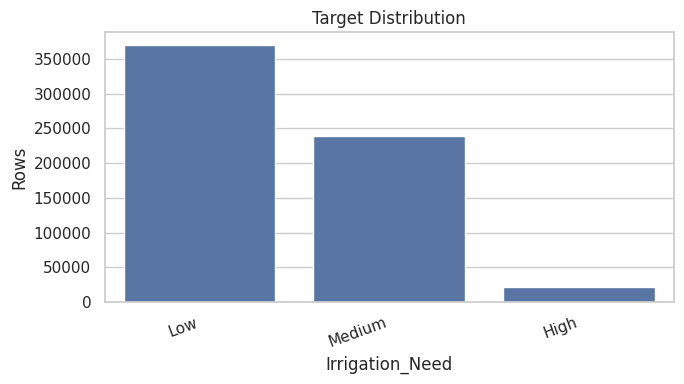

In [7]:
target_counts = train[target_col].value_counts(dropna=False)
target_pct = train[target_col].value_counts(normalize=True, dropna=False).mul(100)
target_summary = pd.concat([target_counts.rename('count'), target_pct.rename('pct')], axis=1)
display(target_summary)

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=train, x=target_col, order=target_counts.index, ax=ax)
ax.set_title('Target Distribution')
ax.set_xlabel(target_col)
ax.set_ylabel('Rows')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 5. Missingness

In [8]:
missing = pd.DataFrame({
    'train_missing_pct': train[feature_cols].isna().mean().mul(100),
    'test_missing_pct': test[[c for c in feature_cols if c in test.columns]].isna().mean().mul(100),
}).fillna(0)
missing['abs_diff_pct'] = (missing['train_missing_pct'] - missing['test_missing_pct']).abs()

display(missing.sort_values(['train_missing_pct', 'abs_diff_pct'], ascending=False).head(30))

plot_missing = missing[(missing['train_missing_pct'] > 0) | (missing['test_missing_pct'] > 0)].sort_values('train_missing_pct', ascending=False)
if plot_missing.empty:
    print('No missing values found in train/test features.')
else:
    ax = plot_missing[['train_missing_pct', 'test_missing_pct']].head(40).plot(kind='bar', figsize=(12, 5))
    ax.set_title('Missing Values by Feature')
    ax.set_ylabel('Missing %')
    ax.set_xlabel('Feature')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

,train_missing_pct,test_missing_pct,abs_diff_pct
Soil_Type,0.0000,0.0000,0.0000
Soil_pH,0.0000,0.0000,0.0000
Soil_Moisture,0.0000,0.0000,0.0000
Organic_Carbon,0.0000,0.0000,0.0000
Electrical_Conductivity,0.0000,0.0000,0.0000
Temperature_C,0.0000,0.0000,0.0000
Humidity,0.0000,0.0000,0.0000
Rainfall_mm,0.0000,0.0000,0.0000
Sunlight_Hours,0.0000,0.0000,0.0000
Wind_Speed_kmh,0.0000,0.0000,0.0000


No missing values found in train/test features.


## 6. Numeric Feature Summary

In [9]:
if numeric_cols:
    display(train[numeric_cols].describe().T)
else:
    print('No numeric features detected.')

,count,mean,std,min,25%,50%,75%,max
Soil_pH,"630,000.0000",6.4825,0.9225,4.8000,5.6900,6.4400,7.2700,8.2000
Soil_Moisture,"630,000.0000",37.3045,16.3771,8.0000,23.3400,37.7500,51.2700,64.9900
Organic_Carbon,"630,000.0000",0.9229,0.3658,0.3000,0.6100,0.9100,1.2200,1.6000
Electrical_Conductivity,"630,000.0000",1.7446,0.9523,0.1000,0.9300,1.7400,2.5800,3.5000
Temperature_C,"630,000.0000",26.9982,8.6236,12.0000,19.5175,26.9600,34.5400,42.0000
Humidity,"630,000.0000",61.5632,19.7082,25.0000,45.3900,61.6500,79.1200,94.9900
Rainfall_mm,"630,000.0000","1,462.2076",612.9897,0.3800,954.5700,"1,467.1600","2,054.2800","2,499.6900"
Sunlight_Hours,"630,000.0000",7.5134,1.9993,4.0000,5.7600,7.5800,9.2500,11.0000
Wind_Speed_kmh,"630,000.0000",10.3754,5.6895,0.5000,5.2800,10.4800,15.4300,20.0000
Field_Area_hectare,"630,000.0000",7.5177,4.2181,0.3000,3.8800,7.3800,11.1400,15.0000


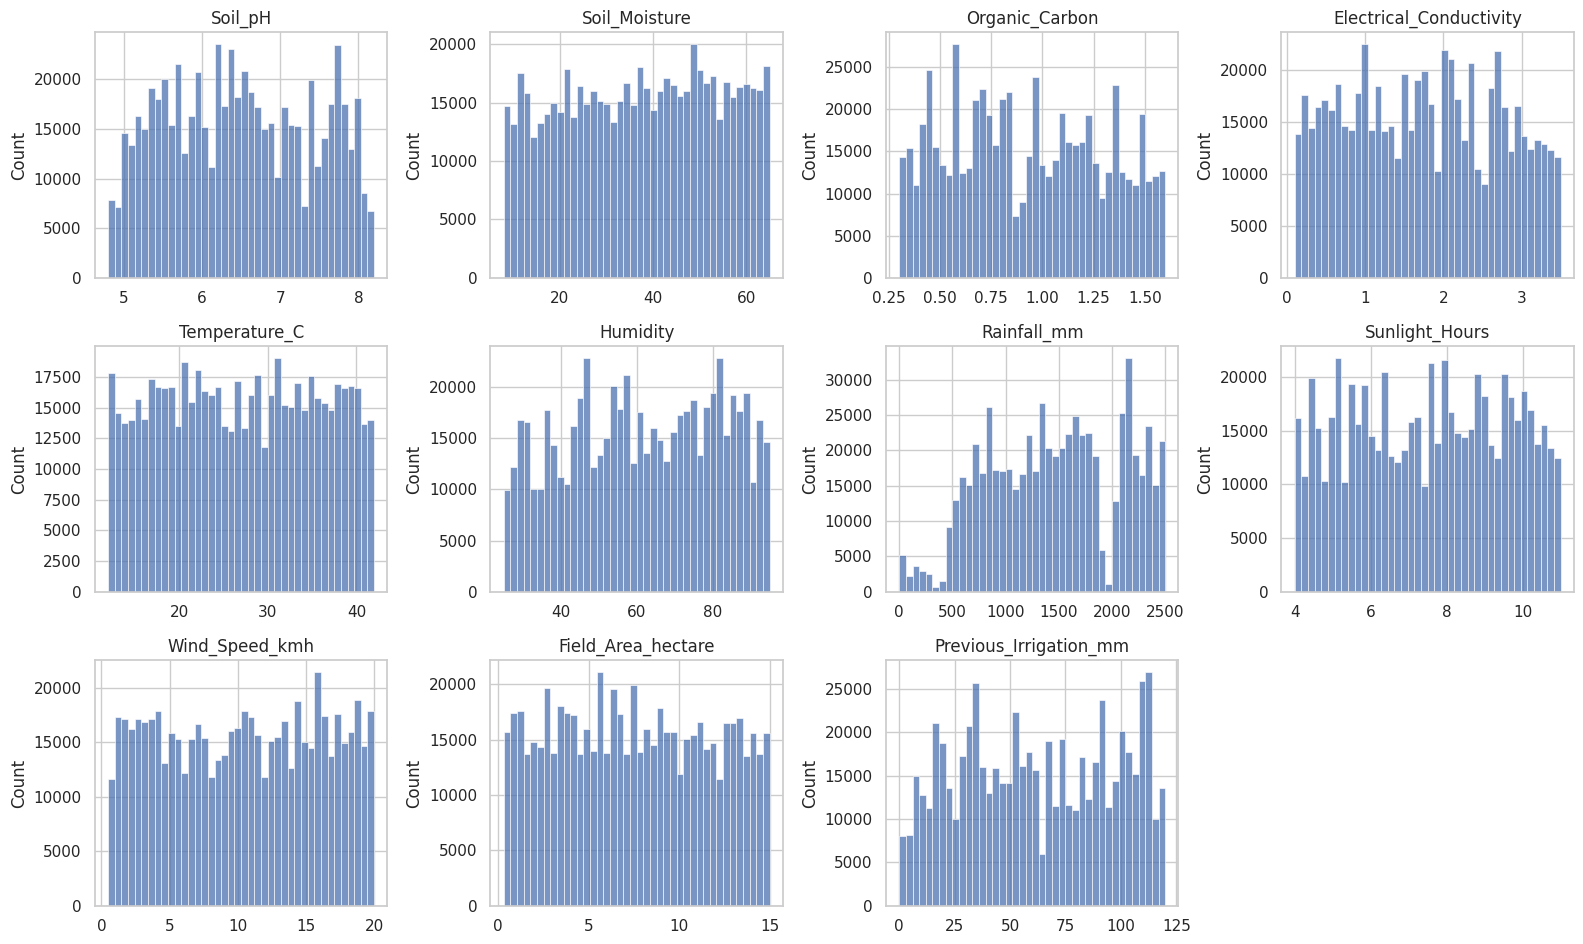

In [10]:
def plot_numeric_histograms(df, cols, max_cols=16):
    cols = cols[:max_cols]
    if not cols:
        print('No numeric columns to plot.')
        return
    ncols = 4
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        sns.histplot(df[col], bins=40, kde=False, ax=ax)
        ax.set_title(col)
        ax.set_xlabel('')
    for ax in axes[len(cols):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_numeric_histograms(train, numeric_cols, max_cols=24)

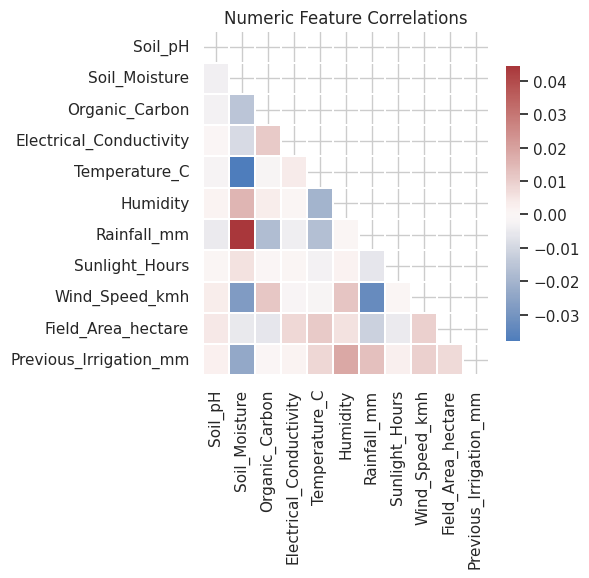

In [11]:
if numeric_cols:
    corr = train[numeric_cols].corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(min(18, 1 + 0.45 * len(numeric_cols)), min(14, 1 + 0.45 * len(numeric_cols))))
    sns.heatmap(corr, mask=mask, cmap='vlag', center=0, linewidths=0.3, cbar_kws={'shrink': 0.8})
    plt.title('Numeric Feature Correlations')
    plt.tight_layout()
    plt.show()
else:
    print('No numeric features detected.')

## 7. Feature Behavior by Target

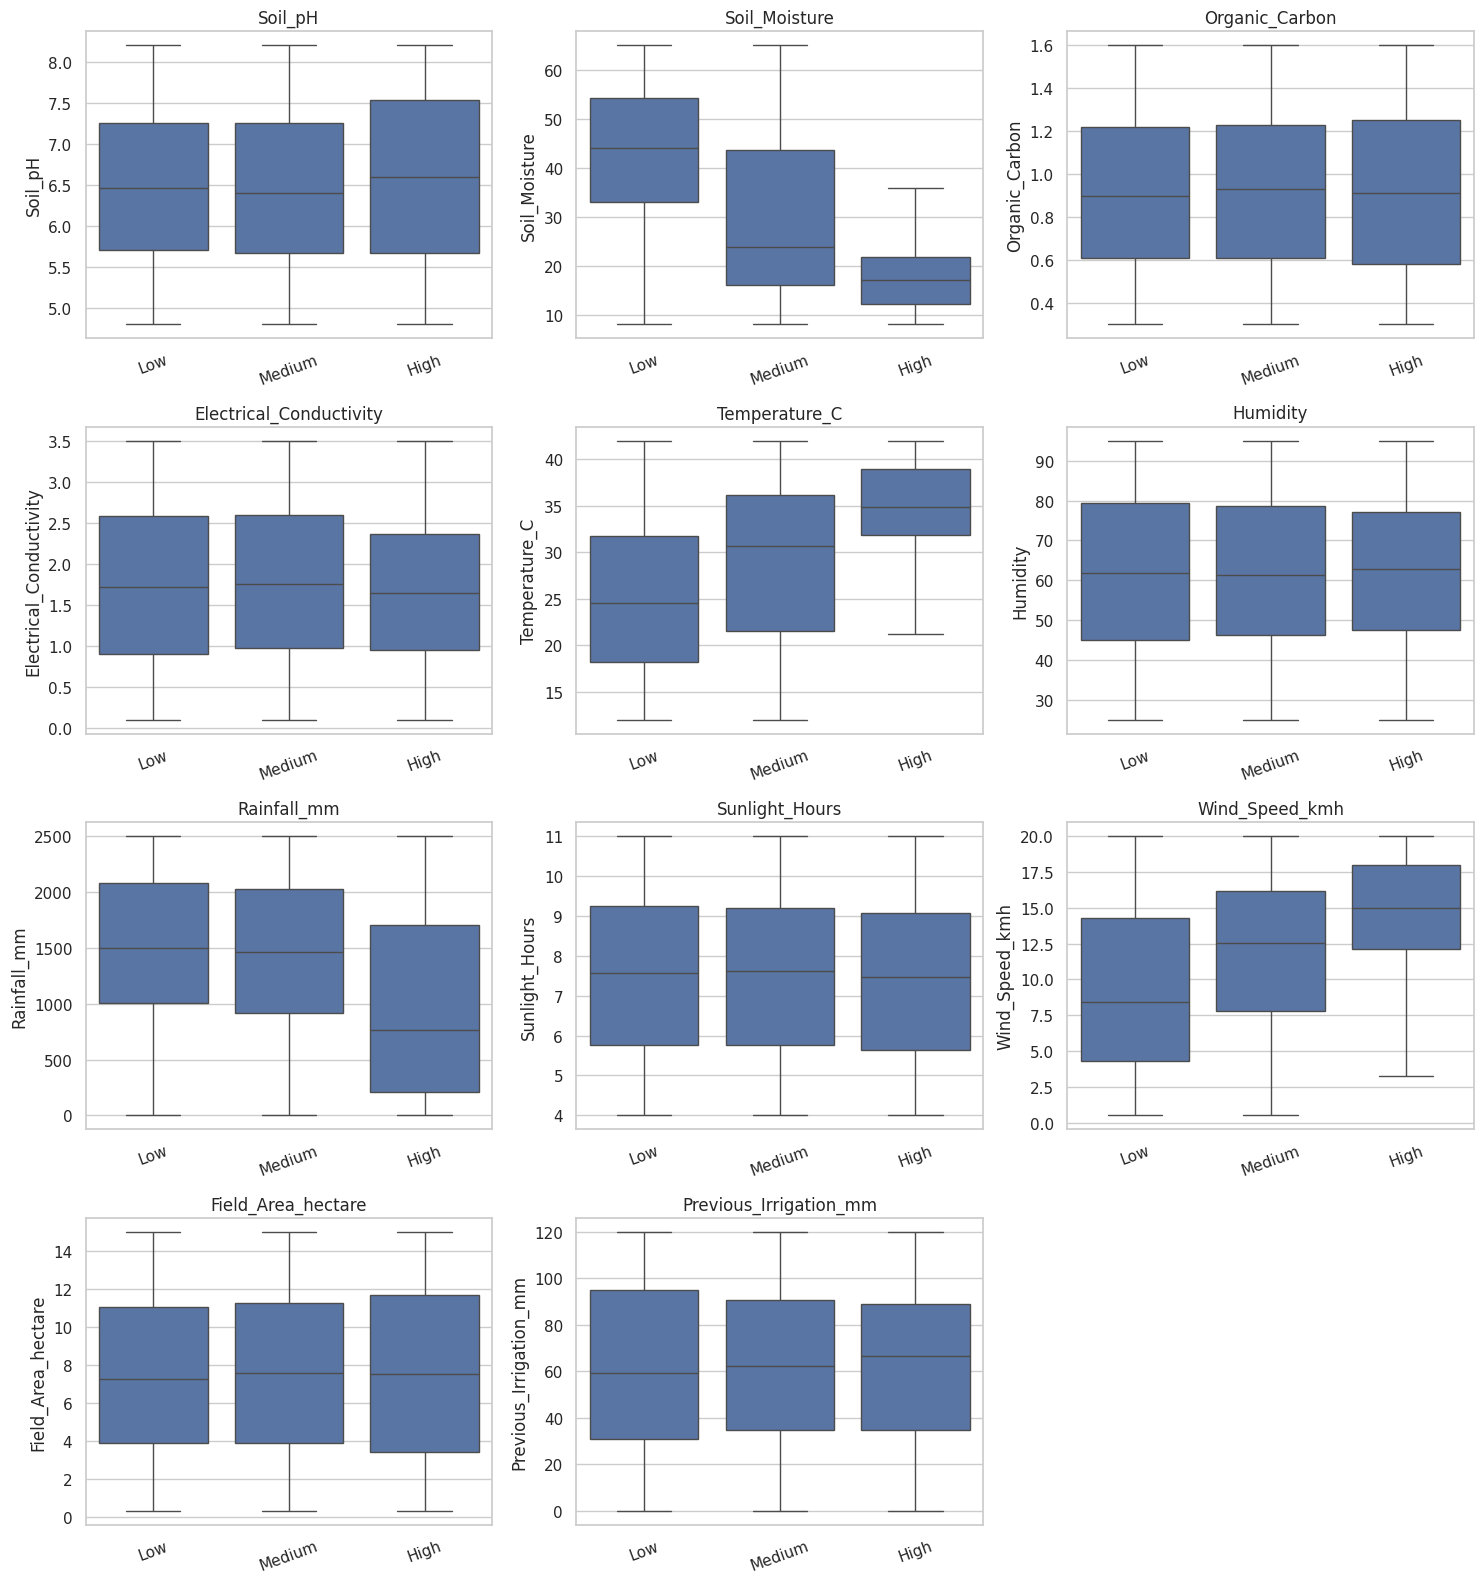

In [12]:
if numeric_cols:
    top_numeric = numeric_cols[:12]
    ncols = 3
    nrows = int(np.ceil(len(top_numeric) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, top_numeric):
        sns.boxplot(data=train, x=target_col, y=col, ax=ax, showfliers=False)
        ax.set_title(col)
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=20)
    for ax in axes[len(top_numeric):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No numeric features detected.')

Irrigation_Need,High,Low,Medium
Soil_Type,,,
Clay,0.0351,0.5870,0.3780
Loamy,0.0288,0.5993,0.3719
Sandy,0.0387,0.5763,0.3850
Silt,0.0303,0.5868,0.3829


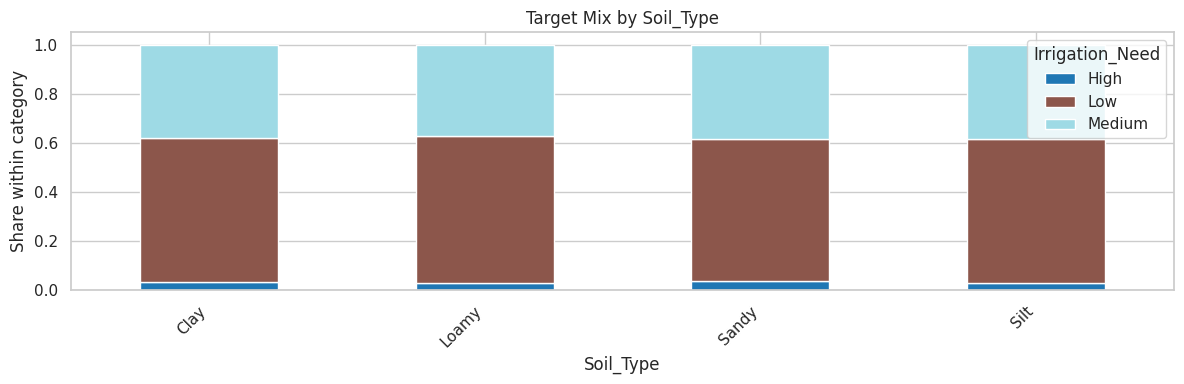

Irrigation_Need,High,Low,Medium
Crop_Type,,,
Cotton,0.0361,0.5872,0.3767
Maize,0.0422,0.5701,0.3877
Potato,0.0274,0.5759,0.3967
Rice,0.0234,0.5999,0.3768
Sugarcane,0.0392,0.5929,0.3680
Wheat,0.0317,0.5965,0.3718


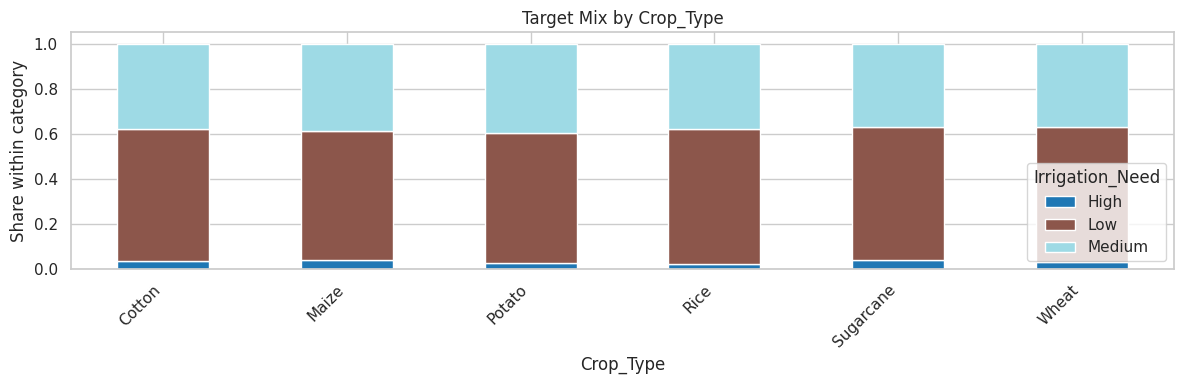

Irrigation_Need,High,Low,Medium
Crop_Growth_Stage,,,
Flowering,0.0644,0.3060,0.6296
Harvest,0.0032,0.8479,0.1489
Sowing,0.0016,0.8718,0.1265
Vegetative,0.0641,0.3238,0.6121


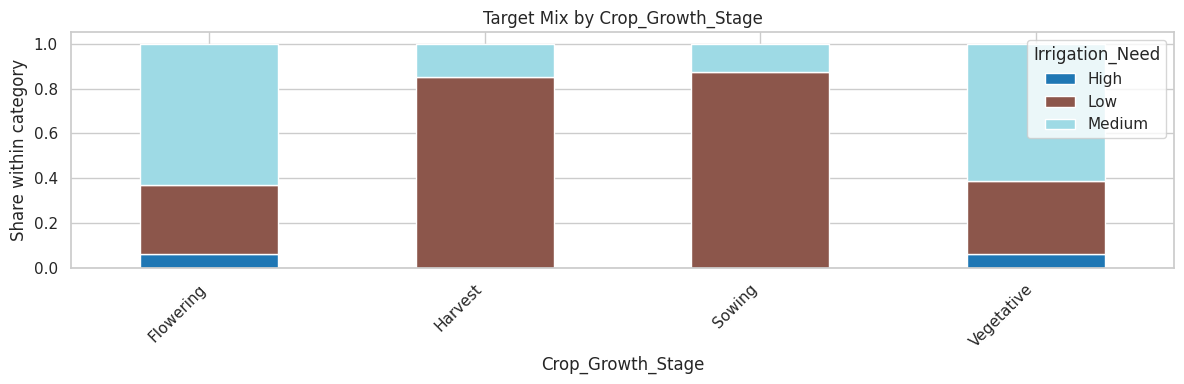

Irrigation_Need,High,Low,Medium
Season,,,
Kharif,0.0348,0.5713,0.3938
Rabi,0.0321,0.5998,0.3681
Zaid,0.0330,0.5911,0.3759


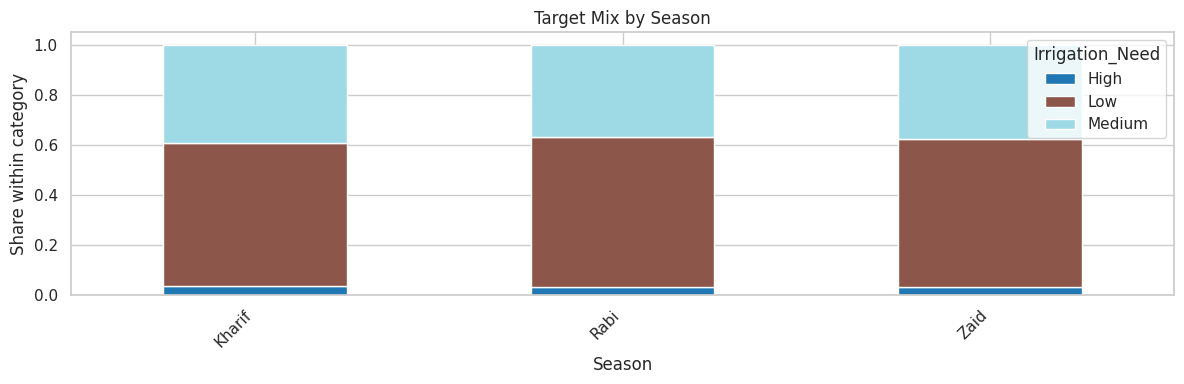

Irrigation_Need,High,Low,Medium
Irrigation_Type,,,
Canal,0.0382,0.5580,0.4039
Drip,0.0267,0.5946,0.3787
Rainfed,0.0332,0.6067,0.3602
Sprinkler,0.0349,0.5907,0.3744


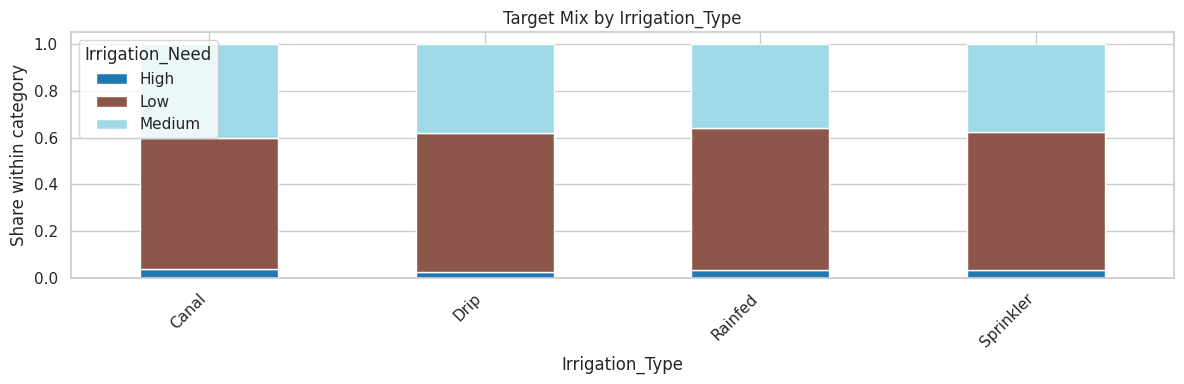

Irrigation_Need,High,Low,Medium
Water_Source,,,
Groundwater,0.0235,0.6010,0.3755
Rainwater,0.0335,0.6037,0.3628
Reservoir,0.0326,0.5626,0.4047
River,0.0434,0.5830,0.3735


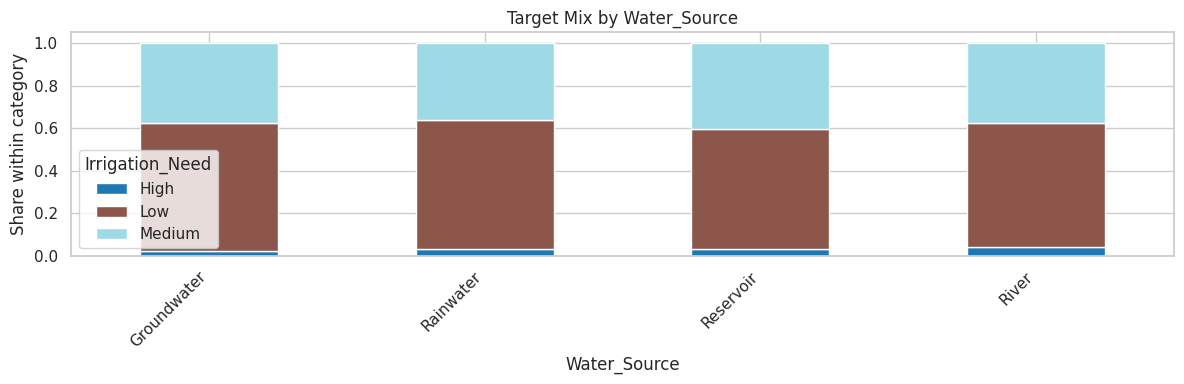

Irrigation_Need,High,Low,Medium
Mulching_Used,,,
No,0.0585,0.4450,0.4964
Yes,0.0079,0.7306,0.2615


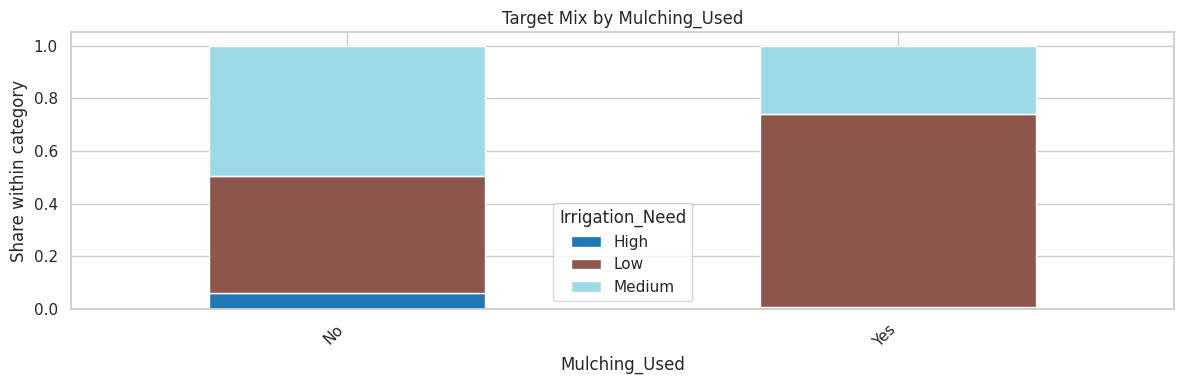

Irrigation_Need,High,Low,Medium
Region,,,
Central,0.0344,0.5930,0.3726
East,0.0287,0.5935,0.3778
North,0.0343,0.5763,0.3895
South,0.0348,0.5865,0.3787
West,0.0346,0.5858,0.3796


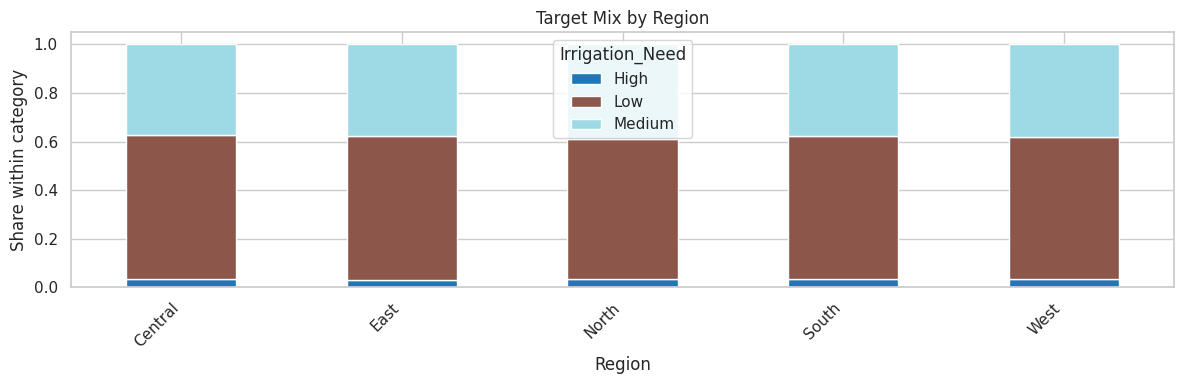

In [13]:
if categorical_cols:
    for col in categorical_cols[:8]:
        ct = pd.crosstab(train[col], train[target_col], normalize='index').sort_index()
        display(ct.head(30))
        ax = ct.head(30).plot(kind='bar', stacked=True, figsize=(12, 4), colormap='tab20')
        ax.set_title(f'Target Mix by {col}')
        ax.set_ylabel('Share within category')
        ax.set_xlabel(col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
else:
    print('No categorical features detected.')

## 8. Train/Test Distribution Checks

In [14]:
common_numeric = [c for c in numeric_cols if c in test.columns]

drift_rows = []
for col in common_numeric:
    train_mean = train[col].mean()
    test_mean = test[col].mean()
    train_std = train[col].std()
    test_std = test[col].std()
    pooled_std = pd.concat([train[col], test[col]], axis=0).std()
    standardized_mean_diff = np.nan if pooled_std == 0 else abs(train_mean - test_mean) / pooled_std
    drift_rows.append({
        'feature': col,
        'train_mean': train_mean,
        'test_mean': test_mean,
        'train_std': train_std,
        'test_std': test_std,
        'standardized_mean_diff': standardized_mean_diff,
    })

drift = pd.DataFrame(drift_rows).sort_values('standardized_mean_diff', ascending=False)
display(drift.head(30))

,feature,train_mean,test_mean,train_std,test_std,standardized_mean_diff
6,Rainfall_mm,"1,462.2076","1,464.5259",612.9897,612.5217,0.0038
5,Humidity,61.5632,61.5113,19.7082,19.6903,0.0026
9,Field_Area_hectare,7.5177,7.5082,4.2181,4.2187,0.0023
8,Wind_Speed_kmh,10.3754,10.3865,5.6895,5.6832,0.0020
0,Soil_pH,6.4825,6.4809,0.9225,0.9222,0.0017
2,Organic_Carbon,0.9229,0.9223,0.3658,0.3658,0.0016
10,Previous_Irrigation_mm,62.3182,62.3560,34.2469,34.2253,0.0011
3,Electrical_Conductivity,1.7446,1.7453,0.9523,0.9513,0.0007
4,Temperature_C,26.9982,27.0017,8.6236,8.6307,0.0004
1,Soil_Moisture,37.3045,37.3076,16.3771,16.3753,0.0002


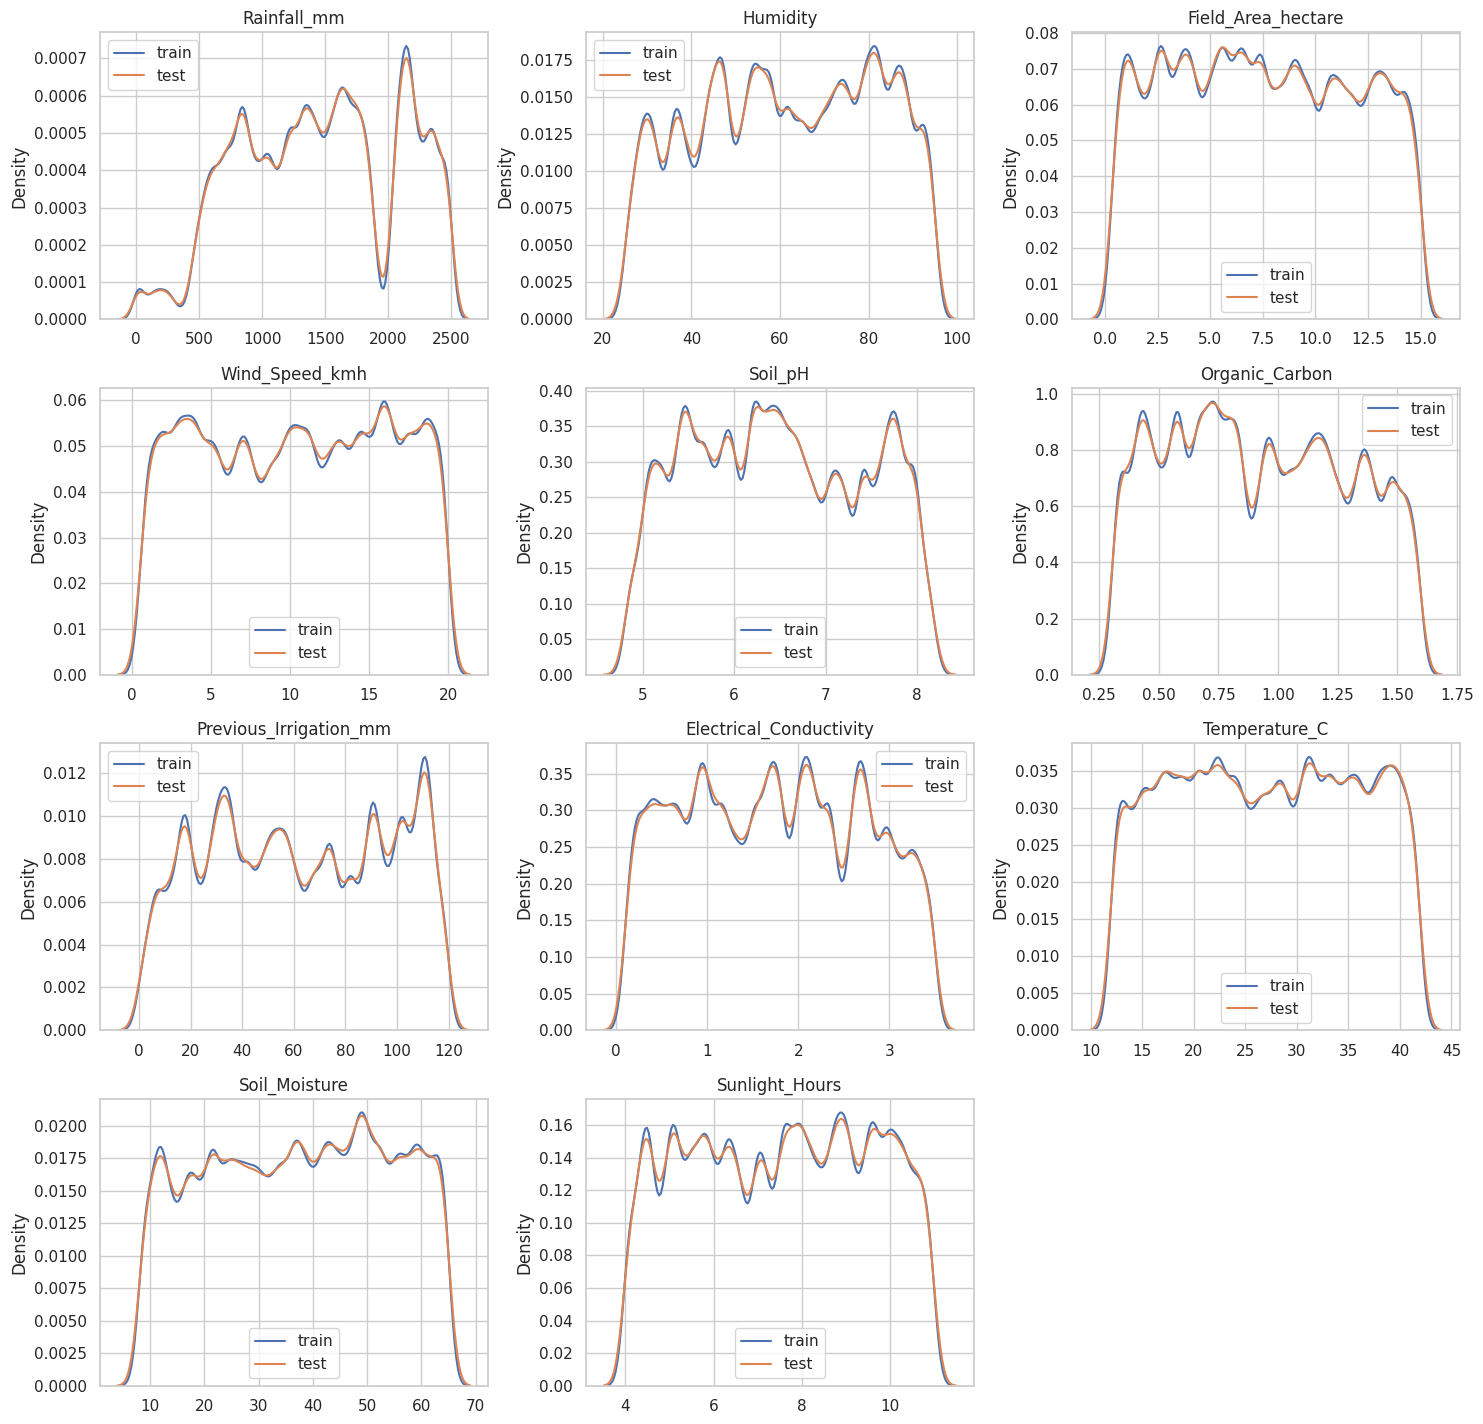

In [15]:
if common_numeric:
    plot_cols = drift['feature'].head(12).tolist()
    ncols = 3
    nrows = int(np.ceil(len(plot_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.6 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, plot_cols):
        sns.kdeplot(train[col], label='train', ax=ax, fill=False)
        sns.kdeplot(test[col], label='test', ax=ax, fill=False)
        ax.set_title(col)
        ax.set_xlabel('')
        ax.legend()
    for ax in axes[len(plot_cols):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No common numeric features detected.')

## 9. Quick Univariate Signal Ranking

,feature,mutual_info
2,Soil_Moisture,0.2053
7,Rainfall_mm,0.1882
11,Crop_Growth_Stage,0.1667
5,Temperature_C,0.0734
9,Wind_Speed_kmh,0.0632
17,Previous_Irrigation_mm,0.0515
6,Humidity,0.0486
16,Mulching_Used,0.0469
4,Electrical_Conductivity,0.0121
3,Organic_Carbon,0.0116


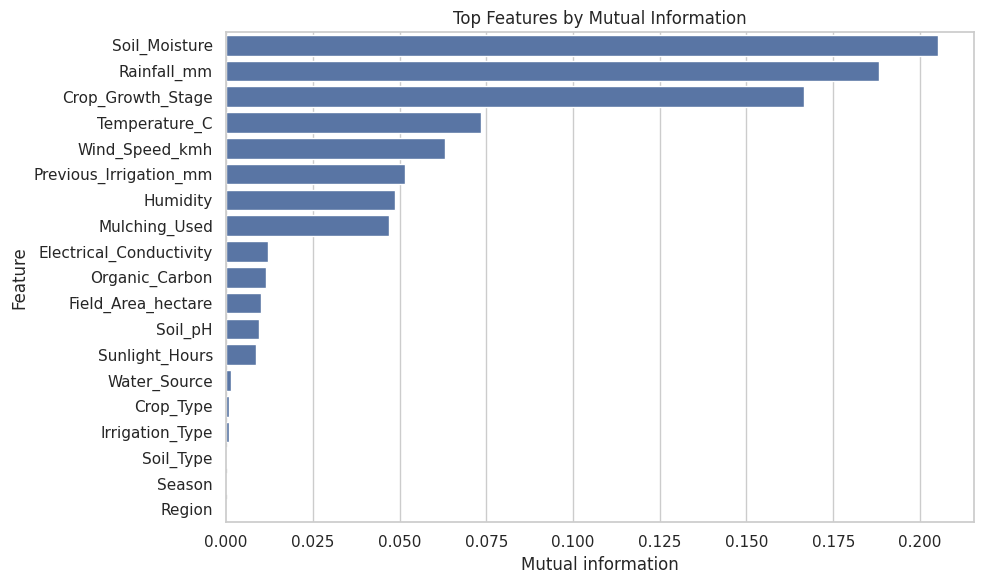

In [16]:
try:
    from sklearn.feature_selection import mutual_info_classif
    from sklearn.preprocessing import OrdinalEncoder

    X = train[feature_cols].copy()
    y = train[target_col]

    cat_cols_for_mi = X.select_dtypes(exclude=np.number).columns.tolist()
    num_cols_for_mi = X.select_dtypes(include=np.number).columns.tolist()

    for col in num_cols_for_mi:
        X[col] = X[col].fillna(X[col].median())

    if cat_cols_for_mi:
        X[cat_cols_for_mi] = X[cat_cols_for_mi].astype('string').fillna('__missing__')
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X[cat_cols_for_mi] = encoder.fit_transform(X[cat_cols_for_mi])

    discrete_mask = [col in cat_cols_for_mi for col in X.columns]
    mi = mutual_info_classif(X, y, discrete_features=discrete_mask, random_state=RANDOM_STATE)
    mi_df = pd.DataFrame({'feature': X.columns, 'mutual_info': mi}).sort_values('mutual_info', ascending=False)
    display(mi_df.head(30))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=mi_df.head(25), x='mutual_info', y='feature')
    plt.title('Top Features by Mutual Information')
    plt.xlabel('Mutual information')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('Skipped mutual information ranking:', repr(exc))

## 10. EDA Notes

Use this section while running on Kaggle to capture observations:

- Target balance:
- Missingness concerns:
- Train/test drift concerns:
- Strong-looking features:
- Feature engineering ideas:
- Validation strategy thoughts: